# Phase 3: Baseline Model Training
**Models:** Logistic Regression, Decision Tree, Naive Bayes, Random Forest, SVM, KNN, XGBoost

**Metrics:** Accuracy, Precision, Recall, F1, AUC-ROC + 5-Fold CV

## Step 1 - Importing All Required Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn models and tools
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

## Step 2 - Loading Preprocessed Data Files from Phase 2
#### Loading the SMOTE-balanced training data and the clean validation data.

In [ ]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive')

# Copying X_train_final.csv from Drive to Colab's disk
!cp "/content/drive/MyDrive/X_train_final.csv" /content/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading Phase 2 Final Datasets
print("Loading Phase 2 final datasets...")
X_train = pd.read_csv('X_train_final.csv')
X_val = pd.read_csv('X_val_final.csv')
X_test = pd.read_csv('X_test_final.csv')
y_train = pd.read_csv('y_train_final.csv').squeeze()
y_val = pd.read_csv('y_val_final.csv').squeeze()
y_test = pd.read_csv('y_test_final.csv').squeeze()

print("✅ Phase 2 data loaded successfully!")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"All features numeric: {X_train.dtypes.unique()}")


Loading Phase 2 final datasets...
✅ Phase 2 data loaded successfully!
X_train: (91314, 2136), y_train: (91314,)
X_val:   (10728, 2136), y_val:   (10728,)
X_test:  (10728, 2136), y_test:  (10728,)
All features numeric: [dtype('float64')]


In [ ]:
# Cleaning XGBoost feature names (remove [ ] < from column names)
X_train = X_train.rename(
    columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_")
)
X_val   = X_val.rename(
    columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_")
)
X_test  = X_test.rename(
    columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_")
)

print("✅ Feature names cleaned for XGBoost/SVM/etc.")


✅ Feature names cleaned for XGBoost/SVM/etc.


## Step 3 - Training & Evaluating All Models (Initialize Models & Setup Cross-Validation)
*Note: The SVM model was excluded from training because it did not perform reliably on the 91,000+ row SMOTE dataset within the available Colab resources.*

*Note: Models were split into two groups to reduce Colab memory load, avoid worker crashes, and make the long XGBoost evaluations run more stably.*

In [ ]:
# Training & Evaluating 4 Tree-Based + Linear Models
models_1 = {
    'Logistic_Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision_Tree': DecisionTreeClassifier(random_state=42),
    'Random_Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Naive_Bayes': GaussianNB()
}

# Training & Evaluating 2 Distance-Based + Boosting Models
models_2 = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
    #'SVM': LinearSVC(random_state=42, max_iter=3000)
}

# Set up 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# List to hold our final metrics
results_1 = []
results_2 = []


Training Logistic_Regression... (Please wait)
✓ 5-Fold CV F1-Score: 0.6757
✓ Model fitted
✓ Metrics calculated

Training Decision_Tree... (Please wait)
✓ 5-Fold CV F1-Score: 0.9200
✓ Model fitted
✓ Metrics calculated

Training Random_Forest... (Please wait)
✓ 5-Fold CV F1-Score: 0.9494
✓ Model fitted
✓ Metrics calculated

Training Naive_Bayes... (Please wait)
✓ 5-Fold CV F1-Score: 0.6863
✓ Model fitted
✓ Metrics calculated


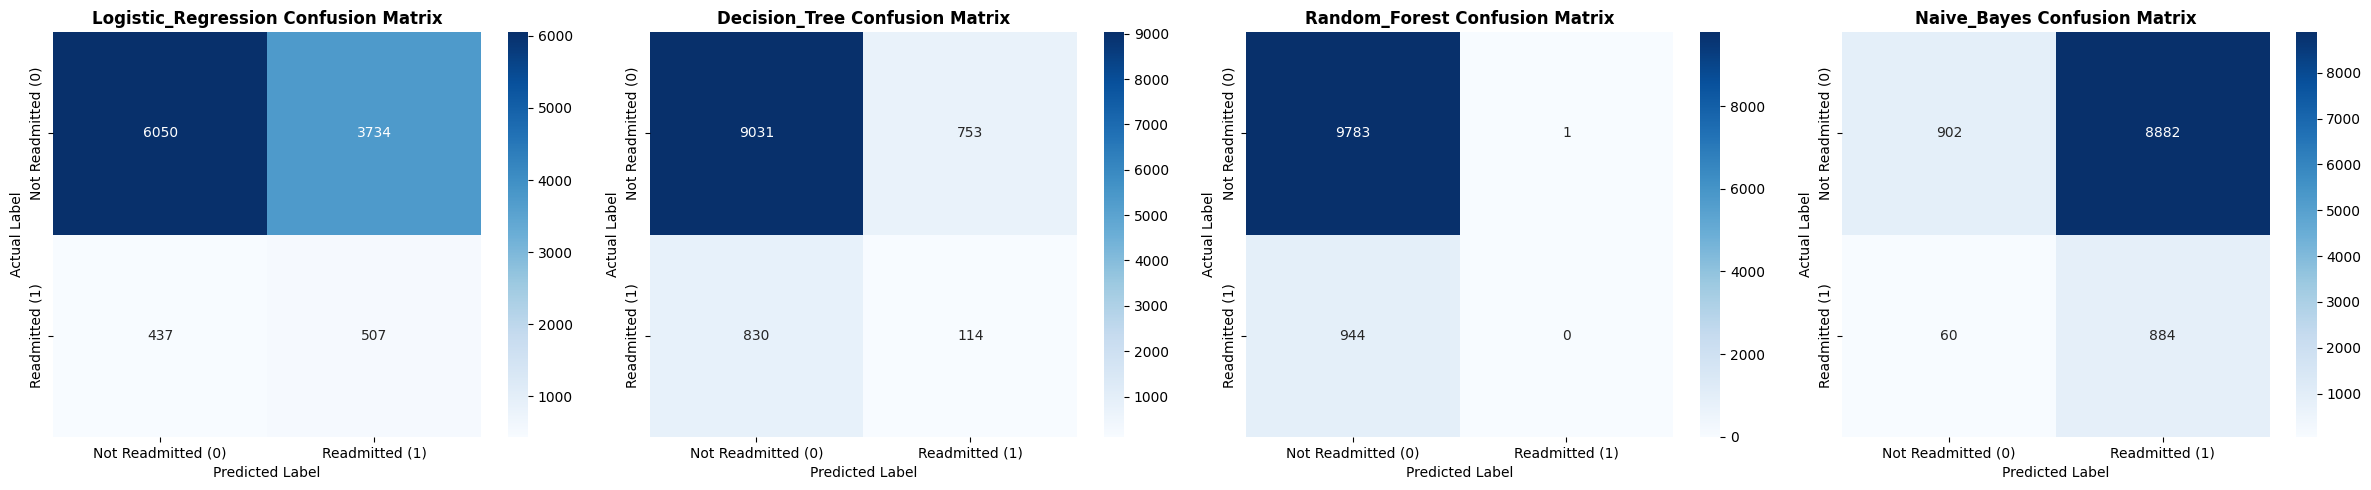

In [ ]:
# Setting up the plot for the 4 confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (name, model) in enumerate(models_1.items()):
    print(f"\n========================================")
    print(f"Training {name}... (Please wait)")

    # 1. Cross Validation on Training Data
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1', n_jobs=1)
    print(f"✓ 5-Fold CV F1-Score: {cv_scores.mean():.4f}")

    # 2. Fit on the full training data
    model.fit(X_train, y_train)
    print("✓ Model fitted")

    # 3. Predict on Validation Data
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] # Probability of class 1

    # 4. Calculate Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)
    print("✓ Metrics calculated")

    # 5. Append to results
    results_1.append({
        'Model': name,
        'Val_Accuracy': acc,
        'Val_Precision': prec,
        'Val_Recall': rec,
        'Val_F1': f1,
        'Val_AUC': auc,
        'CV_F1_Mean': cv_scores.mean()
    })

    # 6. Generate Confusion Matrix Plot
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Readmitted (0)', 'Readmitted (1)'],
                yticklabels=['Not Readmitted (0)', 'Readmitted (1)'])
    axes[i].set_title(f'{name} Confusion Matrix', fontweight='bold')
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


Training KNN... (Please wait)
✓ 5-Fold CV F1-Score: 0.8457
✓ Model fitted
✓ Metrics calculated

Training XGBoost... (Please wait)
✓ 5-Fold CV F1-Score: 0.9476
✓ Model fitted
✓ Metrics calculated


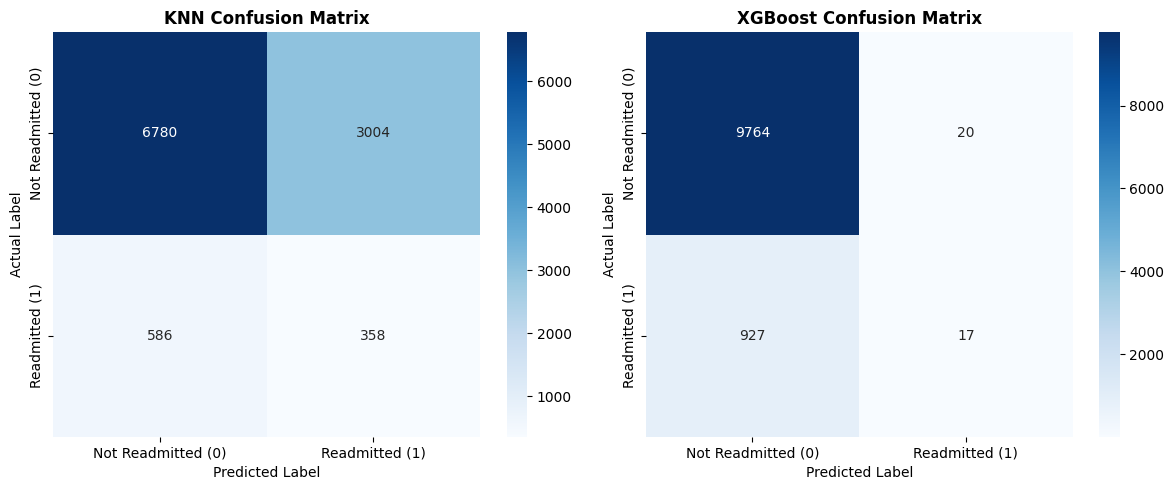

In [ ]:
# Set up the plot for the 2 confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models_2.items()):
    print(f"\n========================================")
    print(f"Training {name}... (Please wait)")

    # 1. Cross Validation on Training Data
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1', n_jobs=1)
    print(f"✓ 5-Fold CV F1-Score: {cv_scores.mean():.4f}")

    # 2. Fit on the full training data
    model.fit(X_train, y_train)
    print("✓ Model fitted")

    # 3. Predict on Validation Data
    y_pred = model.predict(X_val)

    if name == 'SVM':
        y_score = model.decision_function(X_val)
    else:
        y_score = model.predict_proba(X_val)[:, 1] # Probability of class 1

    # 4. Calculate Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_score)
    print("✓ Metrics calculated")

    # 5. Append to results
    results_2.append({
        'Model': name,
        'Val_Accuracy': acc,
        'Val_Precision': prec,
        'Val_Recall': rec,
        'Val_F1': f1,
        'Val_AUC': auc,
        'CV_F1_Mean': cv_scores.mean()
    })

    # 6. Generate Confusion Matrix Plot
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Readmitted (0)', 'Readmitted (1)'],
                yticklabels=['Not Readmitted (0)', 'Readmitted (1)'])
    axes[i].set_title(f'{name} Confusion Matrix', fontweight='bold')
    axes[i].set_ylabel('Actual Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Step 4 - Exporting and Displaying the Results
#### Saving the metrics to a CSV.

In [ ]:
# combining both of the results
results = pd.concat([pd.DataFrame(results_1), pd.DataFrame(results_2)], ignore_index=True)

results_df = pd.DataFrame(results)

print("==================================================")
print("         DISPLAY RESULTS FOR ALL MODELS           ")
print("==================================================")
display(results_df)

         DISPLAY RESULTS FOR ALL MODELS           


,Model,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_AUC,CV_F1_Mean
0,Logistic_Regression,0.611204,0.119547,0.537076,0.195564,0.600981,0.675682
1,Decision_Tree,0.852442,0.131488,0.120763,0.125897,0.521900,0.920012
2,Random_Forest,0.911913,0.000000,0.000000,0.000000,0.598165,0.949416
3,Naive_Bayes,0.166480,0.090518,0.936441,0.165079,0.514346,0.686260
4,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658
5,XGBoost,0.911726,0.459459,0.018008,0.034659,0.633806,0.947584
6,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658
7,XGBoost,0.911726,0.459459,0.018008,0.034659,0.633806,0.947584


In [ ]:
# Exporting the Results to CSV
file_name = 'Phase3_results.csv'
results_df.to_csv(file_name, index=False)
print(f"\n✓ Successfully exported to {file_name}")


✓ Successfully exported to Phase3_results.csv


## Step 5 - Plotting ROC Curves for All Models
#### This section generates ROC curves for every trained model using the validation set probabilities.

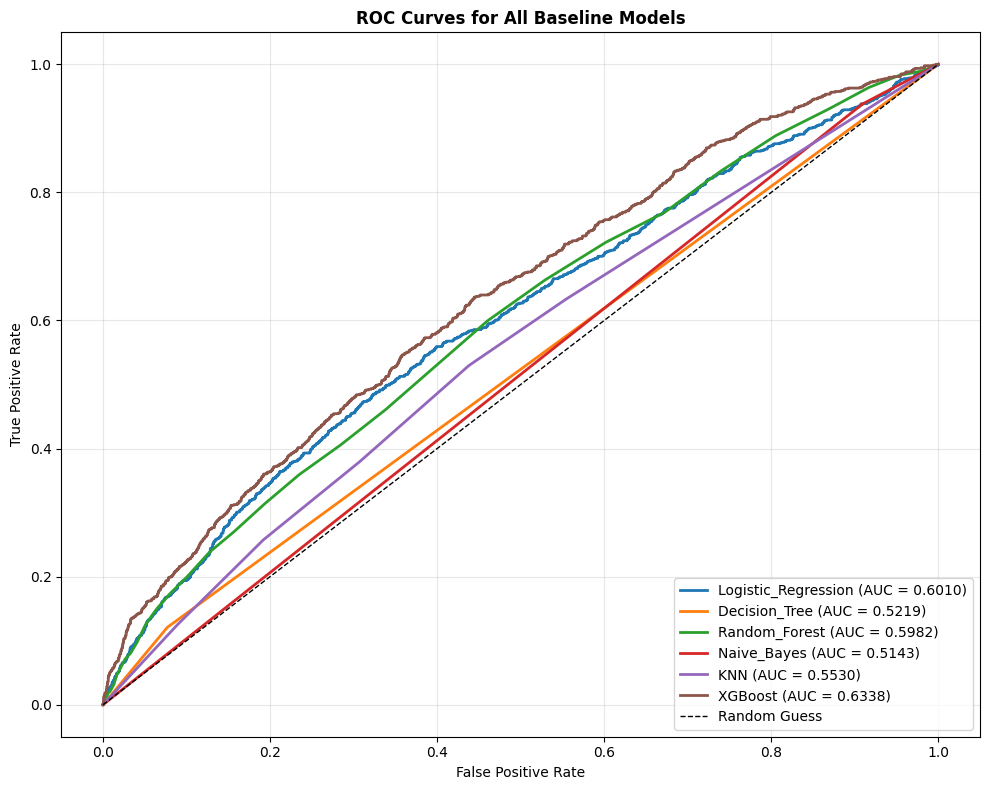

In [ ]:
from sklearn.metrics import roc_curve, auc

# Setting up the ROC curve plot
plt.figure(figsize=(10, 8))

# Combining both the model sets into one
models = {**models_1, **models_2}

# Plotting ROC curve for each model
for name, model in models.items():
    if name == 'SVM':
        y_score = model.decision_function(X_val)
    else:
        y_score = model.predict_proba(X_val)[:, 1]

    # Computing ROC curve
    fpr, tpr, thresholds = roc_curve(y_val, y_score)
    roc_auc = auc(fpr, tpr)

    # Plotting curve
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Plotting the random baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')

# Formatting
plt.title('ROC Curves for All Baseline Models', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 - Ranking the Models
#### Sorting the results by validation F1-score and AUC to identify the best-performing models.

In [ ]:
# Sorting by Validation F1-score
f1_ranked = results_df.sort_values(by='Val_F1', ascending=False)

print("==================================================")
print("        MODELS RANKED BY VALIDATION F1           ")
print("==================================================")
display(f1_ranked)

# Sorting by Validation AUC
auc_ranked = results_df.sort_values(by='Val_AUC', ascending=False)

print("==================================================")
print("        MODELS RANKED BY VALIDATION AUC          ")
print("==================================================")
display(auc_ranked)

        MODELS RANKED BY VALIDATION F1           


,Model,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_AUC,CV_F1_Mean
0,Logistic_Regression,0.611204,0.119547,0.537076,0.195564,0.600981,0.675682
4,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658
6,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658
3,Naive_Bayes,0.166480,0.090518,0.936441,0.165079,0.514346,0.686260
1,Decision_Tree,0.852442,0.131488,0.120763,0.125897,0.521900,0.920012
5,XGBoost,0.911726,0.459459,0.018008,0.034659,0.633806,0.947584
7,XGBoost,0.911726,0.459459,0.018008,0.034659,0.633806,0.947584
2,Random_Forest,0.911913,0.000000,0.000000,0.000000,0.598165,0.949416


        MODELS RANKED BY VALIDATION AUC          


,Model,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_AUC,CV_F1_Mean
7,XGBoost,0.911726,0.459459,0.018008,0.034659,0.633806,0.947584
5,XGBoost,0.911726,0.459459,0.018008,0.034659,0.633806,0.947584
0,Logistic_Regression,0.611204,0.119547,0.537076,0.195564,0.600981,0.675682
2,Random_Forest,0.911913,0.000000,0.000000,0.000000,0.598165,0.949416
4,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658
6,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658
1,Decision_Tree,0.852442,0.131488,0.120763,0.125897,0.521900,0.920012
3,Naive_Bayes,0.166480,0.090518,0.936441,0.165079,0.514346,0.686260


## Step 7 - Selecting the Best Models
#### Choose the best 2 - 3 models based on both F1-score and AUC-ROC.

In [ ]:
# Selecting the top 3 models by a combined ranking idea
# Here we prioritize F1 first, then AUC as a tie-breaker
top_models = results_df.sort_values(
    by=['Val_F1', 'Val_AUC'],
    ascending=[False, False]
).head(3)

print("==================================================")
print("         TOP 3 MODELS FOR FINAL COMPARISON         ")
print("==================================================")
display(top_models)

         TOP 3 MODELS FOR FINAL COMPARISON         


,Model,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Val_AUC,CV_F1_Mean
0,Logistic_Regression,0.611204,0.119547,0.537076,0.195564,0.600981,0.675682
4,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658
6,KNN,0.665362,0.106484,0.379237,0.166280,0.552966,0.845658


## Step 8 - Exporting Final Ranked Results
#### Saving the final ranked tables to CSV

In [ ]:
# Exporting ranked versions for easier reporting
f1_ranked.to_csv('Phase3_results_ranked_by_f1.csv', index=False)
auc_ranked.to_csv('Phase3_results_ranked_by_auc.csv', index=False)
top_models.to_csv('Phase3_top_models.csv', index=False)

print("✓ Exported Phase3_results.csv")
print("✓ Exported Phase3_results_ranked_by_f1.csv")
print("✓ Exported Phase3_results_ranked_by_auc.csv")
print("✓ Exported Phase3_top_models.csv")

✓ Exported Phase3_results.csv
✓ Exported Phase3_results_ranked_by_f1.csv
✓ Exported Phase3_results_ranked_by_auc.csv
✓ Exported Phase3_top_models.csv
